# Analyse Exploratoire des Données (EDA) — Prédiction de retard de paiement

**Objectif de ce notebook :** comprendre les données brutes avant de construire quoi que ce soit
(feature engineering, modèle, pipeline MLOps). On avance étape par étape :

1. Chargement des données et aperçu général
2. Nettoyage des noms de colonnes
3. Vérification des doublons
4. Vérification des valeurs manquantes (null)
5. Vérification de la cohérence des valeurs (valeurs aberrantes / catégories invalides)
6. Analyse de l'équilibre de la variable cible (classe déséquilibrée ou non ?)
7. Statistiques descriptives des variables numériques
8. Distributions des variables clés
9. Corrélations avec la cible
10. Synthèse et prochaines étapes

**Dataset :** [Default of Credit Card Clients Dataset (UCI)](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)
— 30 000 clients de cartes de crédit à Taïwan, avec comme cible `default payment next month`
(1 = le client a fait défaut / retard le mois suivant, 0 = non).


## 1. Imports et chargement des données

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "../default of credit card clients.xls"


: 

Le fichier Excel a un en-tête particulier : la **première ligne** contient des codes génériques
(`X1`, `X2`, ...) et la **deuxième ligne** contient les vrais noms de colonnes (`LIMIT_BAL`, `SEX`, ...).
On indique donc `header=1` pour utiliser la deuxième ligne comme noms de colonnes.

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name=0, header=1)
print("Dimensions (lignes, colonnes) :", df.shape)
df.head()


Dimensions (lignes, colonnes) : (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Nettoyage des noms de colonnes

- `ID` est l'identifiant client (à exclure des features plus tard).
- `PAY_0` est en réalité le retard de paiement de septembre (le doc UCI numérote `PAY_1..PAY_6`
  mais le fichier contient `PAY_0` au lieu de `PAY_1`). On le renomme pour rester cohérent.
- La cible `default payment next month` est renommée en `DEFAULT` pour plus de simplicité.


In [3]:
df = df.rename(columns={
    "PAY_0": "PAY_1",
    "default payment next month": "DEFAULT",
})
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.dtypes


['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']


ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_1        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object

## 3. Vérification des doublons

Deux niveaux à vérifier :
- des **lignes strictement identiques** (toutes colonnes, y compris ID) → anomalie de collecte.
- des **ID clients dupliqués** (même client apparaissant plusieurs fois) → à part, car ID est censé être unique.


In [4]:
n_full_dup = df.duplicated().sum()
print(f"Lignes entièrement dupliquées : {n_full_dup}")

n_id_dup = df["ID"].duplicated().sum()
print(f"ID clients dupliqués : {n_id_dup}")
print(f"ID uniques : {df['ID'].nunique()} / {len(df)} lignes")


Lignes entièrement dupliquées : 0
ID clients dupliqués : 0
ID uniques : 30000 / 30000 lignes


Si des doublons existent, on les affiche pour inspection avant de décider de les supprimer :

In [5]:
if n_full_dup > 0:
    display(df[df.duplicated(keep=False)].sort_values("ID"))
else:
    print("Aucune ligne dupliquée détectée.")


Aucune ligne dupliquée détectée.


## 4. Vérification des valeurs manquantes (null)

On regarde le nombre et le pourcentage de valeurs manquantes par colonne.


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_summary = missing_summary[missing_summary["n_missing"] > 0].sort_values("n_missing", ascending=False)

if missing_summary.empty:
    print("Aucune valeur manquante (NaN) dans le dataset.")
else:
    display(missing_summary)


Aucune valeur manquante (NaN) dans le dataset.


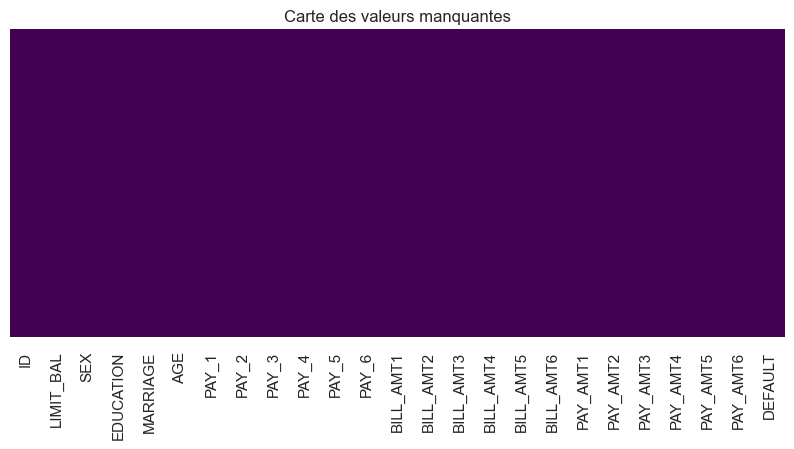

In [7]:
# Visualisation rapide (utile même si vide, pour garder le réflexe sur d'autres jeux de données)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Carte des valeurs manquantes")
plt.show()


## 5. Cohérence des valeurs (valeurs aberrantes / catégories invalides)

L'absence de `NaN` ne veut pas dire que les données sont propres : certaines variables catégorielles
ont des **codes non documentés**. D'après la documentation UCI :

- `SEX` : 1 = homme, 2 = femme
- `EDUCATION` : 1 = graduate school, 2 = university, 3 = high school, 4 = others
  → on va vérifier s'il existe des valeurs **0, 5, 6** (non documentées)
- `MARRIAGE` : 1 = marié, 2 = célibataire, 3 = autre
  → on va vérifier s'il existe une valeur **0** (non documentée)
- `PAY_1..PAY_6` : -2/-1/0 = pas de retard (selon convention), 1-9 = mois de retard


In [8]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())
    print()


--- SEX ---
SEX
1    11888
2    18112
Name: count, dtype: int64

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64



In [9]:
print("Valeurs prises par PAY_1..PAY_6 :")
pay_cols = [f"PAY_{i}" for i in range(1, 7)]
for col in pay_cols:
    print(col, sorted(df[col].unique()))


Valeurs prises par PAY_1..PAY_6 :
PAY_1 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


On regarde aussi les montants (`LIMIT_BAL`, `BILL_AMT*`, `PAY_AMT*`) : des valeurs négatives
sur les montants facturés (`BILL_AMT`) peuvent être normales (crédit en faveur du client), mais
`LIMIT_BAL` négatif ou nul serait suspect.

In [10]:
print("LIMIT_BAL <= 0 :", (df["LIMIT_BAL"] <= 0).sum())
print("AGE min/max :", df["AGE"].min(), "/", df["AGE"].max())

bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_amt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]
print("\nMontants négatifs par colonne :")
print(df[bill_cols + pay_amt_cols].lt(0).sum())


LIMIT_BAL <= 0 : 0
AGE min/max : 21 / 79

Montants négatifs par colonne :
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
PAY_AMT1       0
PAY_AMT2       0
PAY_AMT3       0
PAY_AMT4       0
PAY_AMT5       0
PAY_AMT6       0
dtype: int64


## 6. La variable cible est-elle équilibrée ? (`DEFAULT`)

C'est une étape **critique** avant de choisir une stratégie de modélisation : si la classe
"défaut de paiement" est minoritaire, il faudra adapter la métrique d'évaluation (pas juste
l'accuracy) et éventuellement la stratégie d'entraînement (rééquilibrage, poids de classe...).


In [11]:
counts = df["DEFAULT"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)
balance_df = pd.DataFrame({"count": counts, "pct": pct})
balance_df.index = balance_df.index.map({0: "0 - Pas de défaut", 1: "1 - Défaut"})
display(balance_df)

ratio = counts[0] / counts[1]
print(f"Ratio classe majoritaire / classe minoritaire : {ratio:.2f} : 1")


,count,pct
DEFAULT,,
0 - Pas de défaut,23364,77.88
1 - Défaut,6636,22.12


Ratio classe majoritaire / classe minoritaire : 3.52 : 1


C:\Users\hp\AppData\Local\Temp\ipykernel_24312\162482237.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="DEFAULT", data=df, ax=axes[0], palette="Set2")
C:\Users\hp\AppData\Local\Temp\ipykernel_24312\162482237.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["0 - Pas de défaut", "1 - Défaut"])


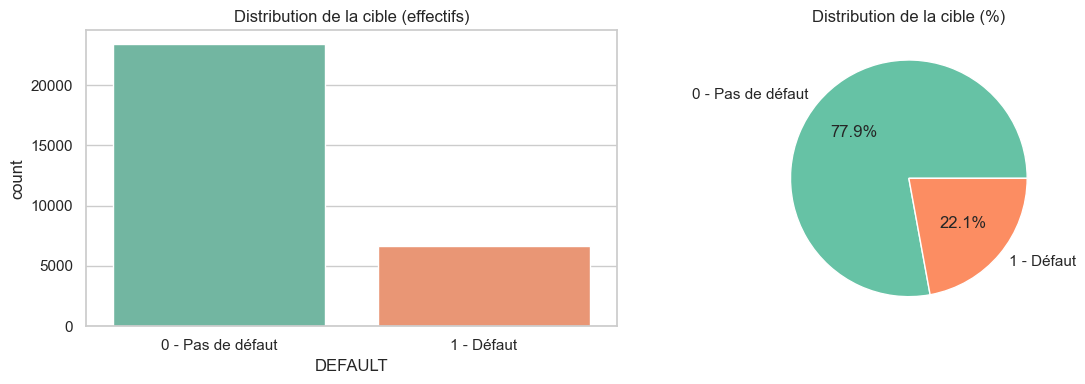

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="DEFAULT", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Distribution de la cible (effectifs)")
axes[0].set_xticklabels(["0 - Pas de défaut", "1 - Défaut"])

axes[1].pie(counts, labels=["0 - Pas de défaut", "1 - Défaut"], autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[1].set_title("Distribution de la cible (%)")

plt.tight_layout()
plt.show()


**Interprétation :** un ratio proche de 1:1 indique un jeu de données équilibré. Un ratio
supérieur à environ 3:1 ou 4:1 est généralement considéré comme un déséquilibre significatif à
prendre en compte (métriques adaptées comme F1/PR-AUC, pondération des classes, sur/sous-échantillonnage, etc.).
On commente ce chiffre concrètement une fois le résultat affiché ci-dessus.

## 7. Statistiques descriptives des variables numériques

In [13]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


On sépare aussi les variables catégorielles (`SEX`, `EDUCATION`, `MARRIAGE`) des variables continues pour une lecture plus claire :

In [14]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = ["LIMIT_BAL", "AGE"] + bill_cols + pay_amt_cols

print("Variables catégorielles :", cat_cols)
print("Variables numériques continues :", num_cols)
print("Variables ordinales (retard de paiement) :", pay_cols)


Variables catégorielles : ['SEX', 'EDUCATION', 'MARRIAGE']
Variables numériques continues : ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Variables ordinales (retard de paiement) : ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


## 8. Distributions des variables clés

On regarde la distribution de `LIMIT_BAL` et `AGE`, globalement et par classe cible, pour repérer
d'éventuelles différences entre clients en défaut et non en défaut.


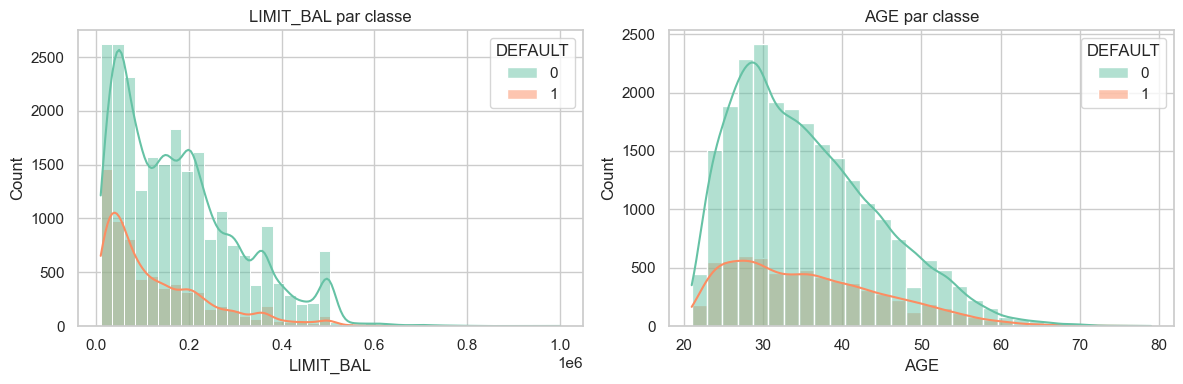

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df, x="LIMIT_BAL", hue="DEFAULT", bins=40, kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("LIMIT_BAL par classe")

sns.histplot(df, x="AGE", hue="DEFAULT", bins=30, kde=True, ax=axes[1], palette="Set2")
axes[1].set_title("AGE par classe")

plt.tight_layout()
plt.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_24312\2374420951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DEFAULT", y="LIMIT_BAL", data=df, palette="Set2")


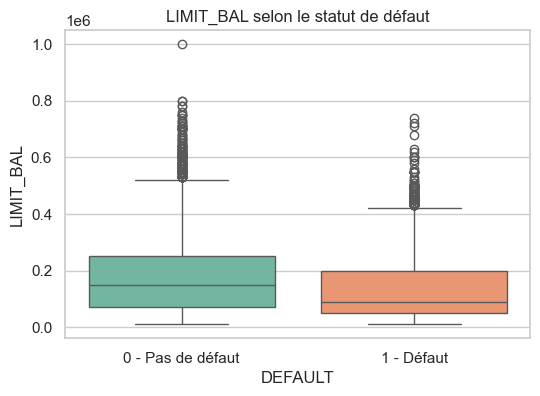

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="DEFAULT", y="LIMIT_BAL", data=df, palette="Set2")
plt.xticks([0, 1], ["0 - Pas de défaut", "1 - Défaut"])
plt.title("LIMIT_BAL selon le statut de défaut")
plt.show()


## 9. Corrélations avec la cible

Une matrice de corrélation (Pearson) donne une première idée des variables les plus liées à la cible
— à interpréter avec prudence puisque plusieurs variables sont catégorielles/ordinales et la relation
peut être non-linéaire.


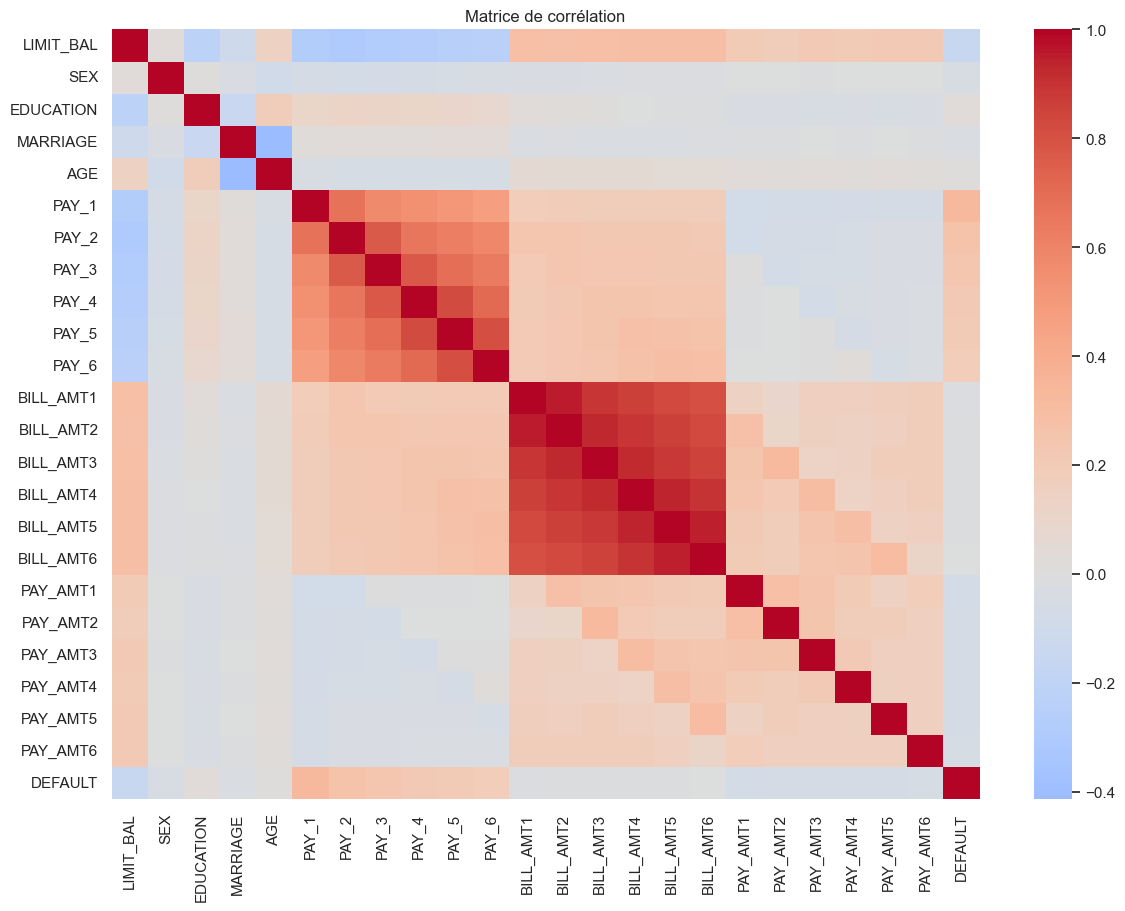

In [17]:
corr = df.drop(columns=["ID"]).corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation")
plt.show()


In [18]:
corr_target = corr["DEFAULT"].drop("DEFAULT").sort_values(key=abs, ascending=False)
print("Corrélation avec DEFAULT (triée par valeur absolue) :")
corr_target


Corrélation avec DEFAULT (triée par valeur absolue) :


PAY_1        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
EDUCATION    0.028006
MARRIAGE    -0.024339
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: DEFAULT, dtype: float64

## 10. Synthèse

À compléter après exécution du notebook, par exemple :

- [ ] Nombre de lignes / colonnes, doublons trouvés (et décision : suppression ou non)
- [ ] Valeurs manquantes trouvées (et stratégie d'imputation si besoin)
- [ ] Catégories invalides détectées (`EDUCATION` 0/5/6, `MARRIAGE` 0) et décision de traitement
- [ ] Niveau de déséquilibre de la cible et implication sur la métrique/stratégie de modélisation
- [ ] Variables les plus corrélées à la cible → pistes de feature engineering

**Prochaine étape du pipeline MLOps :** une fois ces constats validés, on passera à la définition
d'un pipeline de préparation des données (nettoyage, encodage, split train/test) dans un script
réutilisable (hors notebook), avant l'entraînement du modèle.
